<a href="https://colab.research.google.com/github/suhyeon03/DeepLearning/blob/main/3_%EB%8B%A4%EB%B3%80%EB%9F%89_%EC%A0%95%EA%B7%9C_%EB%B6%84%ED%8F%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* 지금까지 살펴본 정규 분포는 하나의 실수값(스칼라)에 대한 정규 분포였다.
* 이번 장에서는 여러 개의 실수로 이루어진 벡터의 정규 분포, 즉 다변량 정규 분포에 대해 알아보자.
* 먼저 벡터와 행렬 같은 기초 개념을 복습한 다음, 이어서 다변량 정규 분포를 시각화하고 최대가능도를 추정하느

# 넘파이와 다차원 배열
## 다차원 배열
* 다차원 배열은 값(원소) 여러 개를 한꺼번에 처리하기 위한 데이터 구조이다.
* 원소의 배열에는 있으며, 이 방향을 축이라고 하고 축의 개수를 차원이라고 한다.
* 0차원 배열, 1차원 배열, 2차원 배열이 있다. 각각을 스칼라, 벡터, 행렬이라고 한다.


## 넘파이의 다차원 배열

In [1]:
import numpy as np

x = np.array([1, 2, 3])
print(x.__class__) # 클래스 이름
print(x.shape) # 형상
print(x.ndim) # 차원 수

<class 'numpy.ndarray'>
(3,)
1


* 이 처럼 벡터와 행렬은 np.array() 함수로 만들 수 있다.
* 이 함수는 다차원 배열인 np.ndarray 인스턴스를 생성한다.
* np.ndarray 인스턴스는 유용한 메서드와 인스턴스 변수를 많이 제공하는데 지금 예에서는 .shape, .ndim을 이용했다.


In [2]:
# 2차원일 경우
W = np.array([[1,2,3],[4,5,6]])
print(W.ndim)
print(W.shape)

[[1 2 3]
 [4 5 6]]


## 원소별 연산

* 형상이 같은 두 넘파이 다차원 배열에 대해 사칙연산인 +, *를 수행한다.
* 이때 다차원 배열의 원소마다 독립적으로 연산이 이루어진다.
* 넘파이로 수행하는 다차원 배열의 '원소별 연산'이다.
* 참고로 원소별 아다마르 곱이라고한다.

In [3]:
W = np.array([[1,2,3],[4,5,6]])
X = np.array([[0,1,2],[3,4,5]])

print(W + X)
print('---')
print(W * X)

[[ 1  3  5]
 [ 7  9 11]]
---
[[ 0  2  6]
 [12 20 30]]


## 벡터의 내적과 행렬 곱
* 벡터의 내적은 두 벡터의 대응하는 원소들의 곱을 모두 더한 값이다.
* 행렬 곱은 왼쪽 행렬의 행 벡터와 오른쪽 행렬의 열 벡터 사이의 내적을 계산하여 새로운 행렬의 원소를 만든다.


In [4]:
# 벡터의 내적
a = np.array([1,2,3])
b = np.array([4,5,6])
y = np.dot(a,b)
print(y)

32


In [6]:
# 행렬 곱
A = np.array([[1,2],[3,4]])
B = np.array([[5,6],[7,8]])
Y = np.dot(A,B)
print(Y)

[[19 22]
 [43 50]]


In [7]:
a @ b # np.dot(a,b)와 같음

np.int64(32)

* 행렬 곱은 형상에 주의해야한다.

# 다변량 정규 분포
* 지금까지 살펴본 정규 분포는 실수값(스칼라) 하나짜리가 대상이였다.
* 예를 들어 키의 분포를 정규 분포로 표현할 때는 관측값의 대상이 키 하나뿐이였다.
* 다음으로 생각해볼 문제는 실숫값 여러 개로 구성된 벡터의 정규 분포이다.
* 다음처럼 원소가 키와 몸무게인 벡터를 생각해보자
* x = (키, 몸무게)

* 이렇게 벡터로 정리하면, 예를 들어 A씨는 (175cm, 50kg)이고 B씨는 (160cm, 53kg)이라는 측정 데이터를 얻을 수 있다.
* 이러한 벡터로 구성된 데이터 분포를 정규 분포로 표현해보는 것이 이번 주제이다.

## 다변량 정규 분포 공식
* 확률 변수 x의 형태는 다음과 같다.

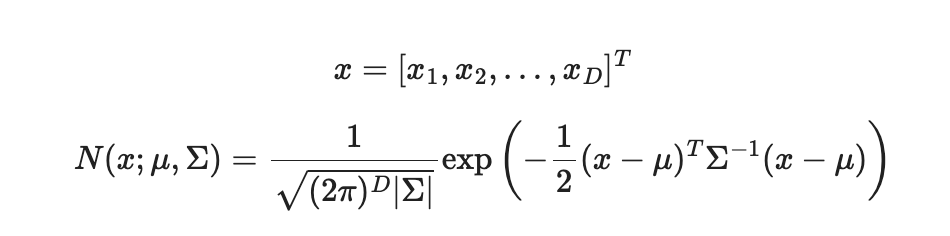

* x는 D개의 확률 변수를 모아놓은 벡터이다.
* 또한 x는 분포가 같은 D개의 독립적인 샘플이 아니다.
* x의 각 원소는 (키와 몸무게처럼) 서로 연관된 데이터로 간주한다.

* 평균 벡터: u
* 공분산 행렬: 시그마(대문자)
* 평균 벡터 u는 원소가 D개로 이루어진 벡터이다.
* 그리고 공분산 행렬 시그마는 DxD 행렬이 되며, 대각선 성분은 각 변수의 분산을, 그 외 성분은 각 변수 사이의 공분산을 나타낸다.

In [8]:
# 행렬의 전치
A = np.array([[1, 2], [3, 4]])
print(A)
print("-" * 3)
print(A.T)

[[1 2]
 [3 4]]
---
[[1 3]
 [2 4]]


In [9]:
# 행렬식의 계산
A = np.array([[1, 2], [3, 4]])
d = np.linalg.det(A)
print(d) # 오차는 LU decomposition 때문에 발생한다고 함

-2.0000000000000004


In [10]:
# 역행렬
A = np.array([[1, 2], [3, 4]])
A_inv = np.linalg.inv(A)
print(A_inv)
print((A @ A_inv).round(1)) # < Identity matrix

[[-2.   1. ]
 [ 1.5 -0.5]]
[[1. 0.]
 [0. 1.]]


## 다변량 정규 분포 구현

In [11]:
import numpy.typing as npt

def multivariate_normal(x, mu: npt.NDArray[np.float32], cov:npt.NDArray[np.float32]) -> np.float32:
    """
    x: (n, )
    mu: (n, )
    cov: (n, n)
    """
    det = np.linalg.det(cov)
    inv = np.linalg.inv(cov)
    D = len(x)
    y = 1 / (np.sqrt((2 * np.pi) ** D * det))
    y *= np.exp(-0.5 * (x - mu).T @ inv @ (x - mu))
    return y

* 인수 x, mu, cov는 모두 ndarray 인스턴스이다.
* x와 mu의 형상은 (1, D)이므로 명확하게 열 벡터이다.
* 또한 넘파이의 특성상, 이번 경우 x와 mu가 (D,)여도 올바르게 계산할 수 있다.
* 그럼 이제 multivariate_normal()함수를 사용해보자.

In [12]:
x = np.array([[0], [0]])  # 또는 x = np.array([0, 0])
mu = np.array([[1], [2]]) # 또는 x = np.array([1, 2])
cov = np.identity(2)

y = multivariate_normal(x, mu, cov)
y

array([[0.01306423]])

* 여기서는 평균 벡터 mu와 공분산 행렬 cov를 적절히 사용하여 (0,0)의 확률 밀도를 계산했다.
* 결과에서 보듯 출력된 확률 밀도는 원소가 하나라서 스칼라값으로 간주할 수 있다.

# 2차원 정규 분포 시각화
## 3D 그래프 그리기


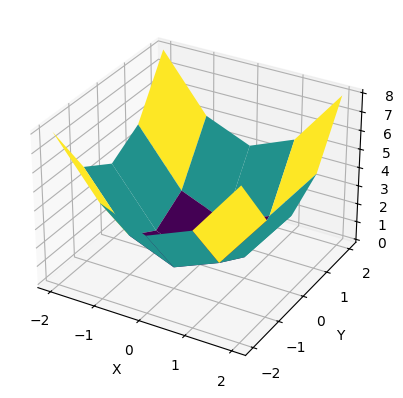

In [13]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [-2, -1, 0, 1, 2],
    [-2, -1, 0, 1, 2],
    [-2, -1, 0, 1, 2],
    [-2, -1, 0, 1, 2],
    [-2, -1, 0, 1, 2]
])

Y = np.array([
    [-2, -2, -2, -2, -2],
    [-1, -1, -1, -1, -1],
    [0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1],
    [2, 2, 2, 2, 2]
])
Z = X ** 2 + Y ** 2

ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis') # type: ignore
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z') # type: ignore
plt.show()

* ax.plot_surface(X, Y, Z, cmap='viridis')의 인수에 주목해보자.
* X, Y, Z는 모두 (5,5) 형상의 2차원 배열이다.
* X와 Y는 코드에서와 같으며 격자 모양으로 늘어선 점들에 해당한다.
* 그리고 Z에는 각 격자점의 3차원 값을 설정했다.
* 예를 들어 X[0,0]은 -2이고 Y[0,0]은 -2이므로, Z[0,0]에는 x=-2이고 y=-2일 때의 z 값을 설정한다.
* 간격을 더 세밀하게 설정하면 더 부드러운 그래프를 만들 수 있다.

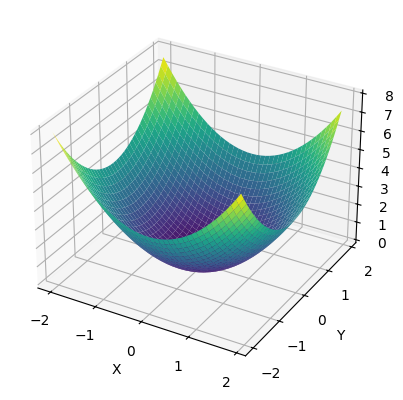

In [14]:
xs = np.arange(-2, 2, .1)
ys = np.arange(-2, 2, .1)
X, Y = np.meshgrid(xs, ys)
Z = X ** 2 + Y ** 2

ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis') # type: ignore
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z') # type: ignore
plt.show()

## 등고선 그리기

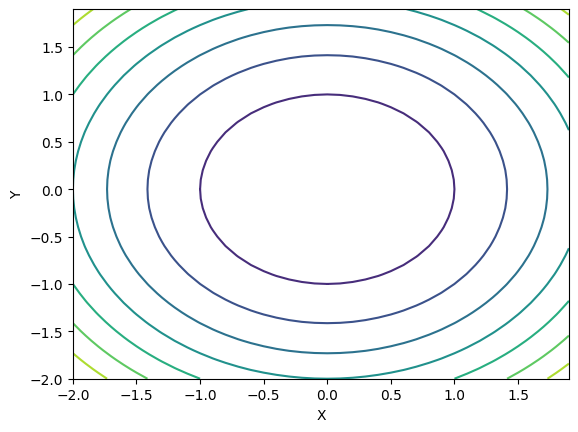

In [15]:
x = np.arange(-2, 2, .1)
y = np.arange(-2, 2, .1)

X, Y = np.meshgrid(x, y)
Z = X ** 2 + Y ** 2

ax = plt.axes()
ax.contour(X, Y, Z)
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.show()

## 2차원 정규 분포 그래프

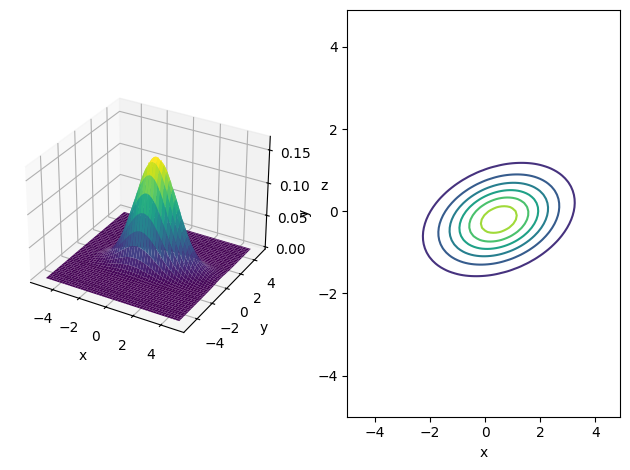

In [16]:
mu = np.array([.5, -.2])
cov = np.array([[2.0, .3], [.3, .5]])

xs = ys = np.arange(-5, 5, .1)
X, Y = np.meshgrid(xs, ys)
Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        x = np.array([X[i, j], Y[i, j]])
        Z[i, j] = multivariate_normal(x, mu, cov)

fig = plt.figure()

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
ax1.plot_surface(X, Y, Z, cmap='viridis')

ax2 = fig.add_subplot(1, 2, 2)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.contour(X, Y, Z)
plt.tight_layout()
plt.show()

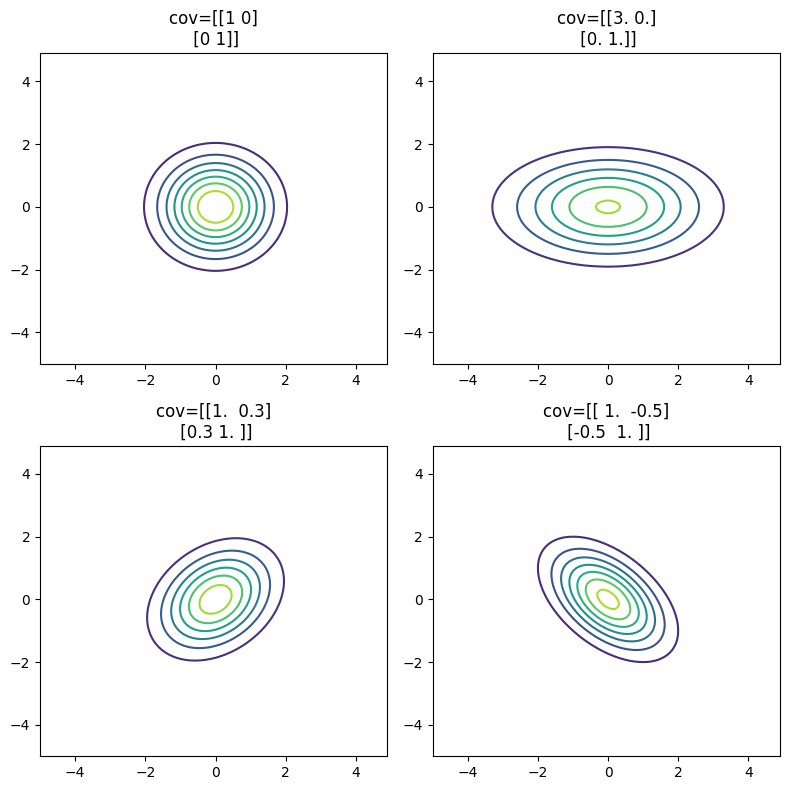

In [17]:
plt.figure(figsize=(8, 8))

mu = np.array([0.0, 0.0])
COVS = [
    np.array([[1, 0], [0, 1]]),
    np.array([[3.0, 0.0], [0.0, 1.0]]),
    np.array([[1.0, 0.3], [0.3, 1.0]]),
    np.array([[1.0, -0.5], [-0.5, 1.0]]),
]

for i, COV in enumerate(COVS):
    plt.subplot(2, 2, i + 1)
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            x = np.array([X[i, j], Y[i, j]])
            Z[i, j] = multivariate_normal(x, mu, COV)
    plt.contour(X, Y, Z)
    plt.title(f'cov={COV}')
plt.tight_layout()
plt.show()

# 다변량 정규 분포의 최대 가능도 추정

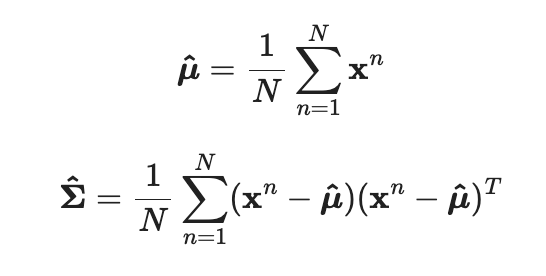

## 최대 가능도 추정 구현

In [18]:
import numpy as np

np.random.seed(0)

N = 10000
D = 2
xs = np.random.rand(N, D) # 균등 분포로부터 더미 데이터 생성

# > calculate mean
mu = np.sum(xs, axis=0) # 1
mu /= N

# > calculate covariance
cov = np.zeros((D, D))
for n in range(N):
    x = xs[n]
    z = x - mu
    z = z[:, np.newaxis] # 2
    cov += z @ z.T

cov /= N

print(mu)
print("---")
print(cov)

[0.49443495 0.49726356]
---
[[ 0.08476319 -0.00023128]
 [-0.00023128  0.08394656]]


* 1 : np.sum(xs, axis=0)에서는 인수를 axis=0으로 설정하여 0번째 축을 따라 합을 구한다.
* 2 : z[:, np.newaxis]는 새로운 축을 추가한다. z의 형상은 원래 (D,)였지만 이 코드를 실행하면 (D,1)로 변한다.

In [19]:
mu = np.mean(xs, axis=0)
cov = np.cov(xs, rowvar=False)

# 실제 데이터 사용

In [20]:
!git clone https://github.com/Rucious-Aladdin/DLFromScratch5.git

Cloning into 'DLFromScratch5'...
remote: Enumerating objects: 162, done.
remote: Counting objects: 100% (162/162), done.
remote: Compressing objects: 100% (126/126), done.
remote: Total 162 (delta 39), reused 144 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (162/162), 27.22 MiB | 18.25 MiB/s, done.
Resolving deltas: 100% (39/39), done.


In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt

path = '/content/DLFromScratch5/Chapter03/height_weight.txt'
xs = np.loadtxt(path) # 파일 불러오기
print(xs.shape) # (25000,)

(25000, 2)


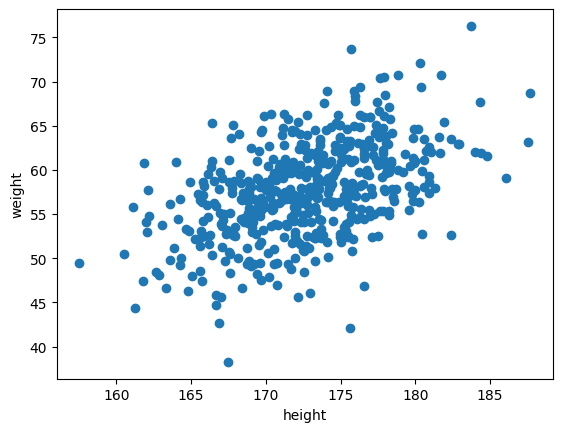

In [24]:
small_xs = xs[:500]
plt.scatter(small_xs[:, 0], small_xs[:, 1])
plt.xlabel('height')
plt.ylabel('weight')
plt.show()

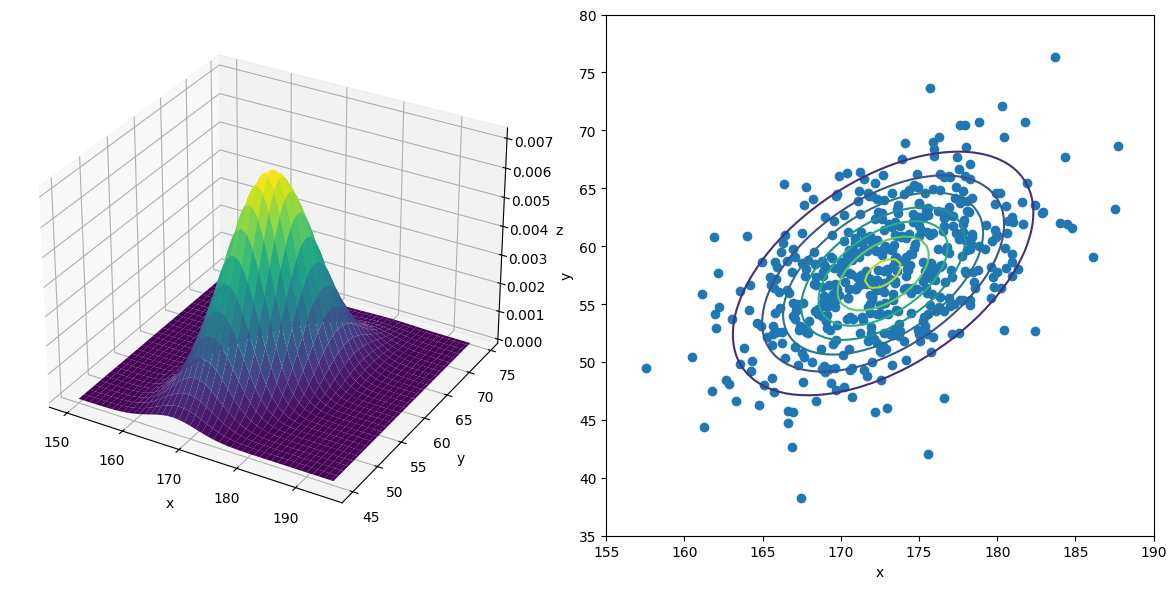

In [25]:
xs = np.loadtxt(path)
mu = np.mean(xs, axis=0)
cov = np.cov(xs, rowvar=False)

xs = np.arange(150.0, 195.0, .5)
ys = np.arange(45.0, 75.0, .5)
X, Y = np.meshgrid(xs, ys)
Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        x = np.array([X[i, j], Y[i, j]])
        Z[i, j] = multivariate_normal(x, mu, cov)

fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
ax1.plot_surface(X, Y, Z, cmap='viridis')

ax2 = fig.add_subplot(1, 2, 2)
ax2.set_ylim(35, 80)
ax2.set_xlim(155, 190)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.contour(X, Y, Z)
ax2.scatter(small_xs[:, 0], small_xs[:, 1])
plt.tight_layout()
plt.show()